In [85]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [86]:
# reading the dataset

from google.colab import drive
drive.mount('/content/drive')

titanic_df = pd.read_csv('/content/drive/MyDrive/DS100 WS2/titanic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Perform basic EDA

In [87]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [89]:
titanic_df.shape

(891, 12)

In [91]:
titanic_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


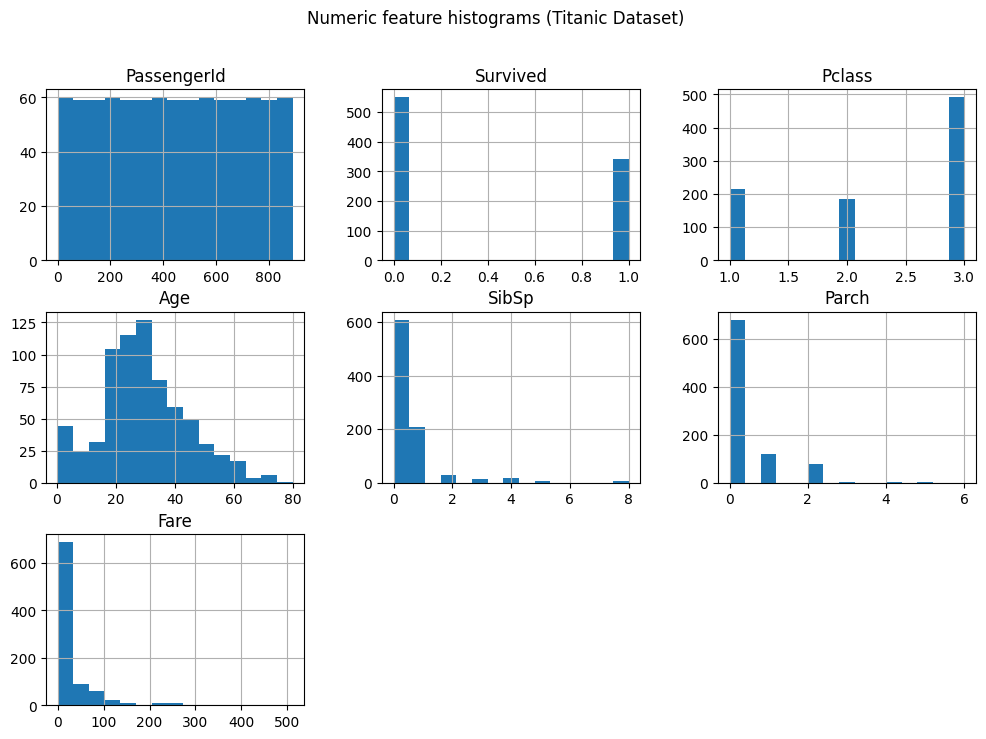

In [92]:
# visual EDA
num_cols = titanic_df.select_dtypes(include=['int64', 'float64'])

num_cols.hist(bins=15, figsize=(12, 8))
plt.suptitle('Numeric feature histograms (Titanic Dataset)')
plt.show()

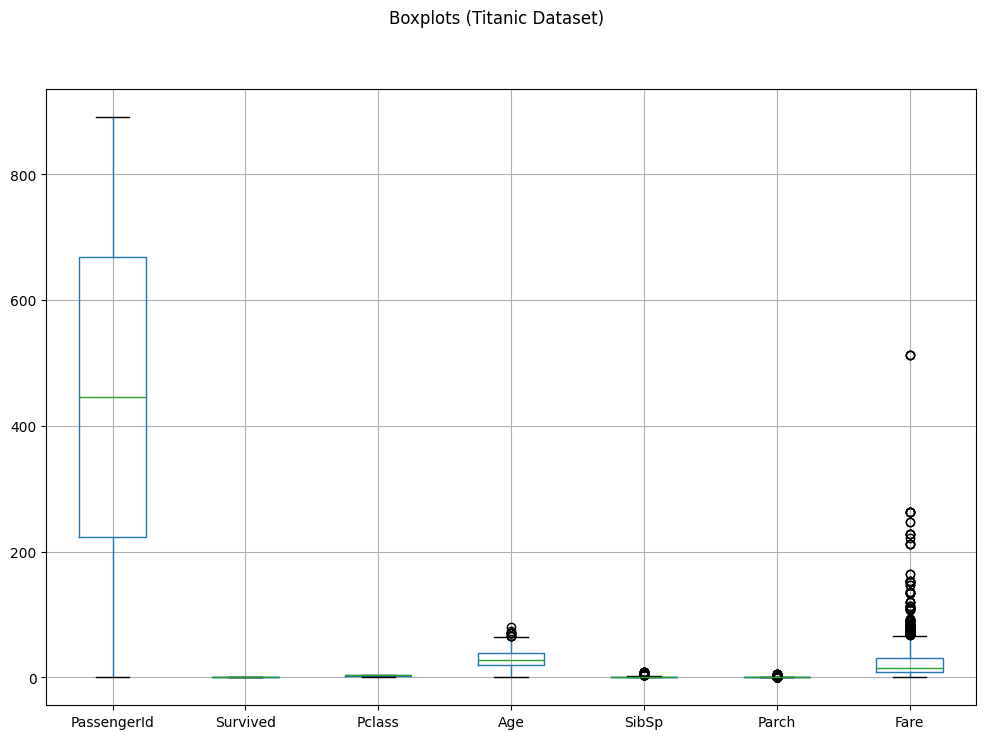

In [93]:
# boxplot to check for outliers
num_cols = titanic_df.select_dtypes(include=['int64', 'float64'])

num_cols.boxplot(figsize=(12, 8))
plt.suptitle('Boxplots (Titanic Dataset)')
plt.show()

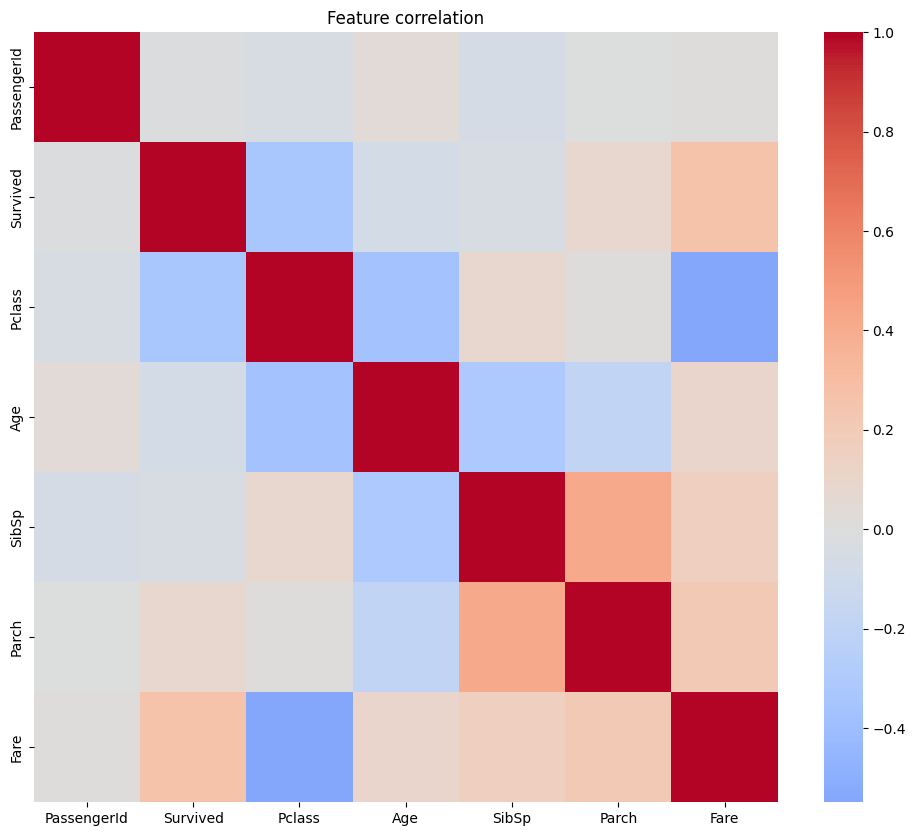

In [94]:
# Correlation heatmap for classification dataset
plt.figure(figsize=(12, 10))

corr = titanic_df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title('Feature correlation')
plt.show()

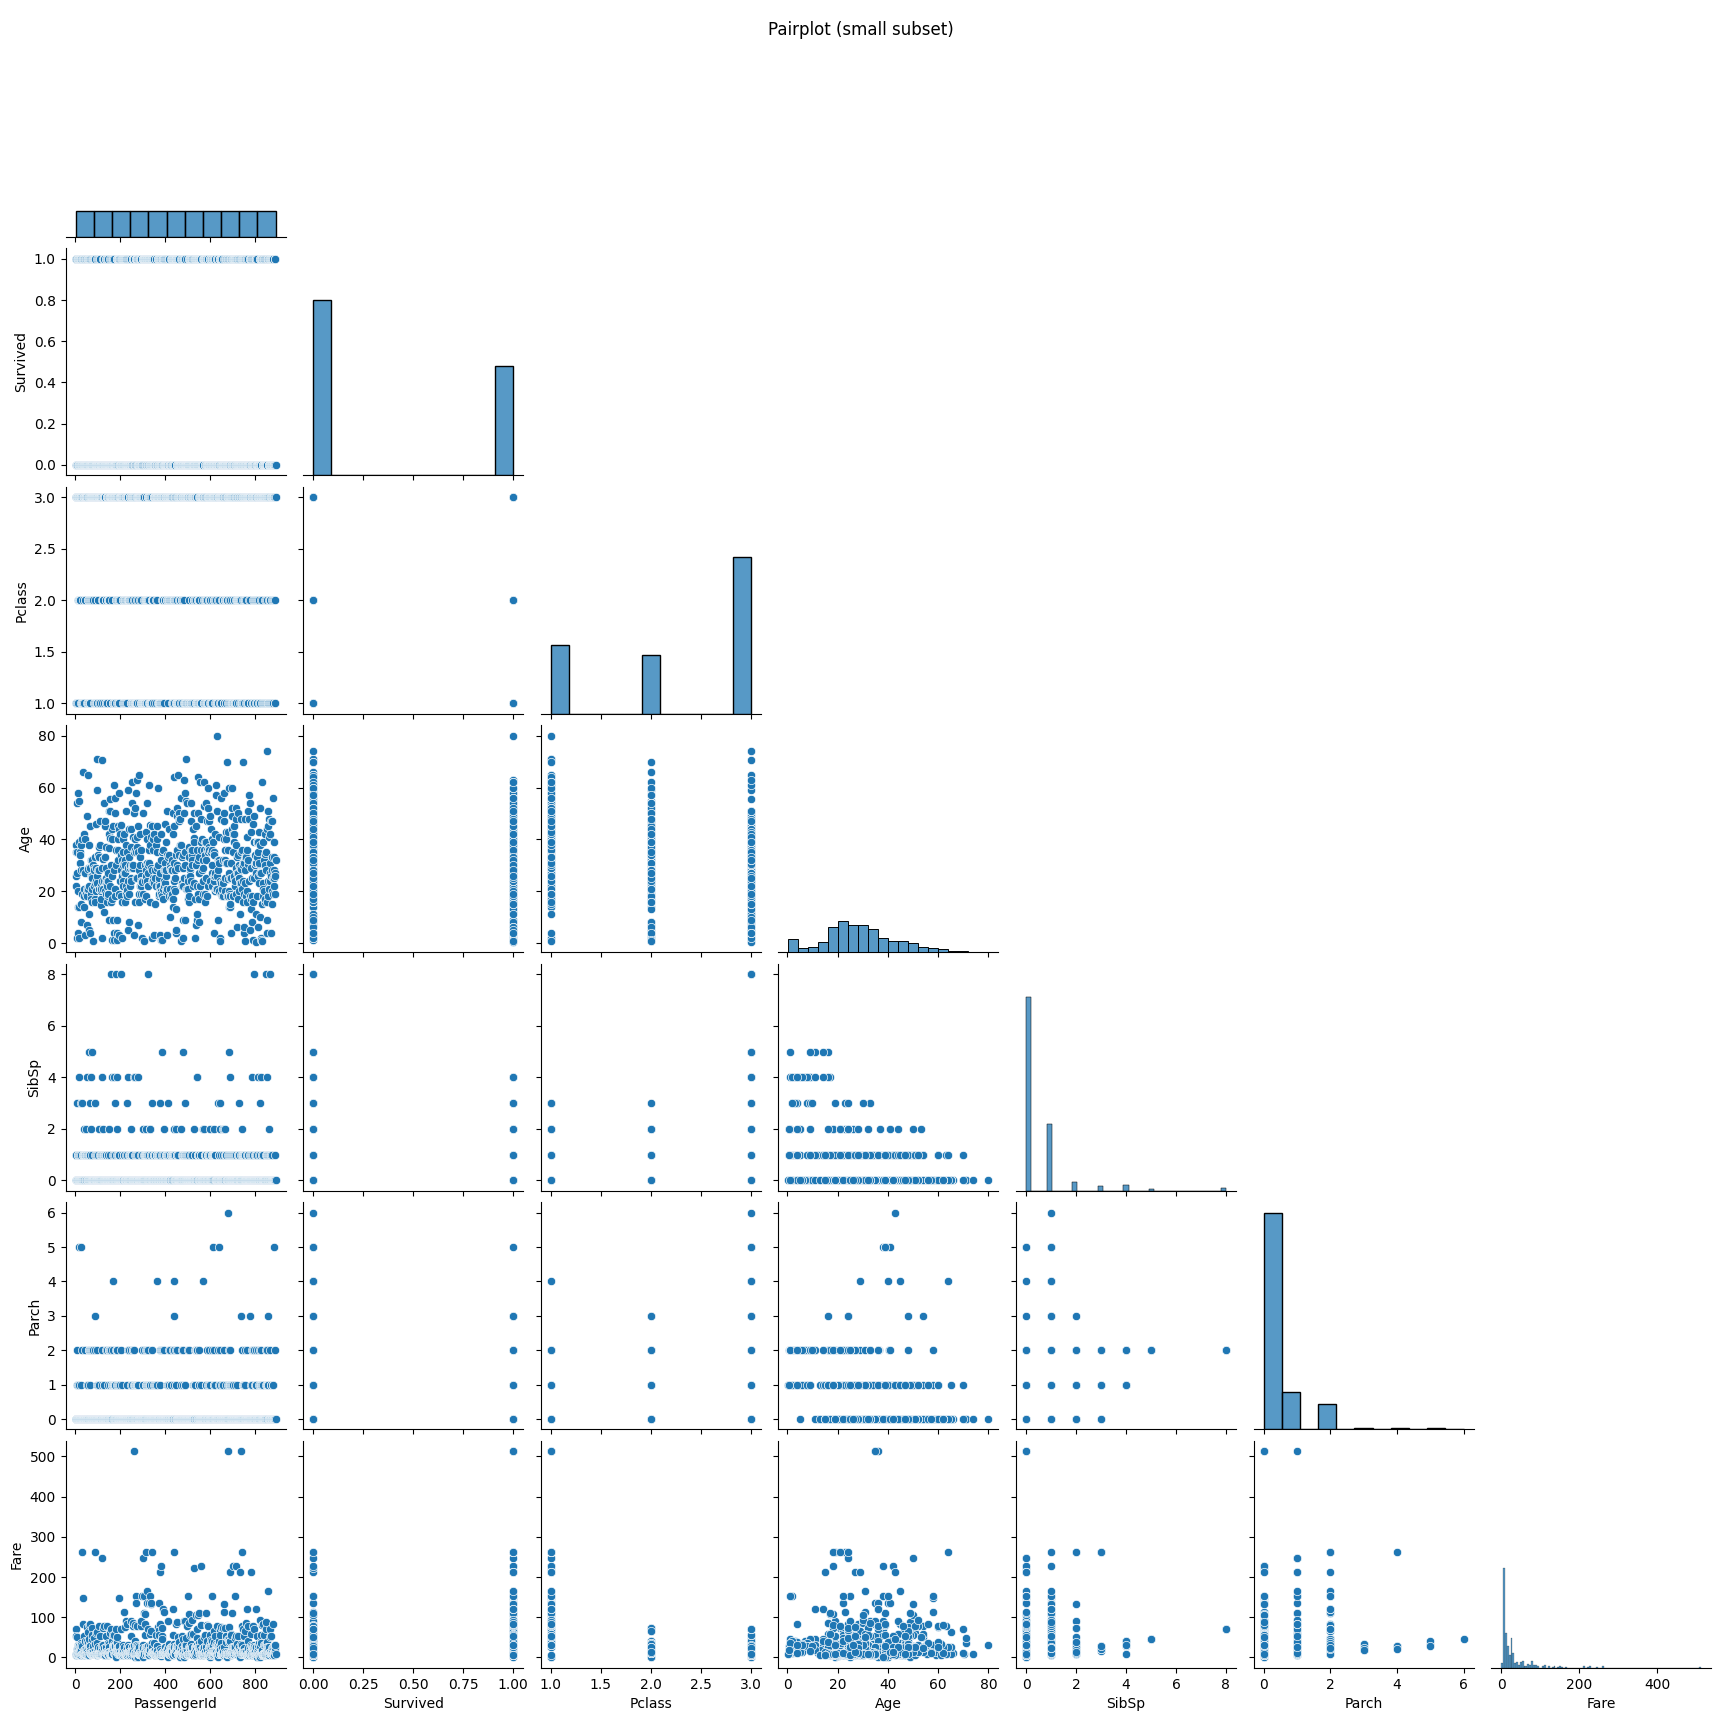

In [95]:
sns.pairplot(titanic_df, corner=True)
plt.suptitle('Pairplot (small subset)')
plt.show()

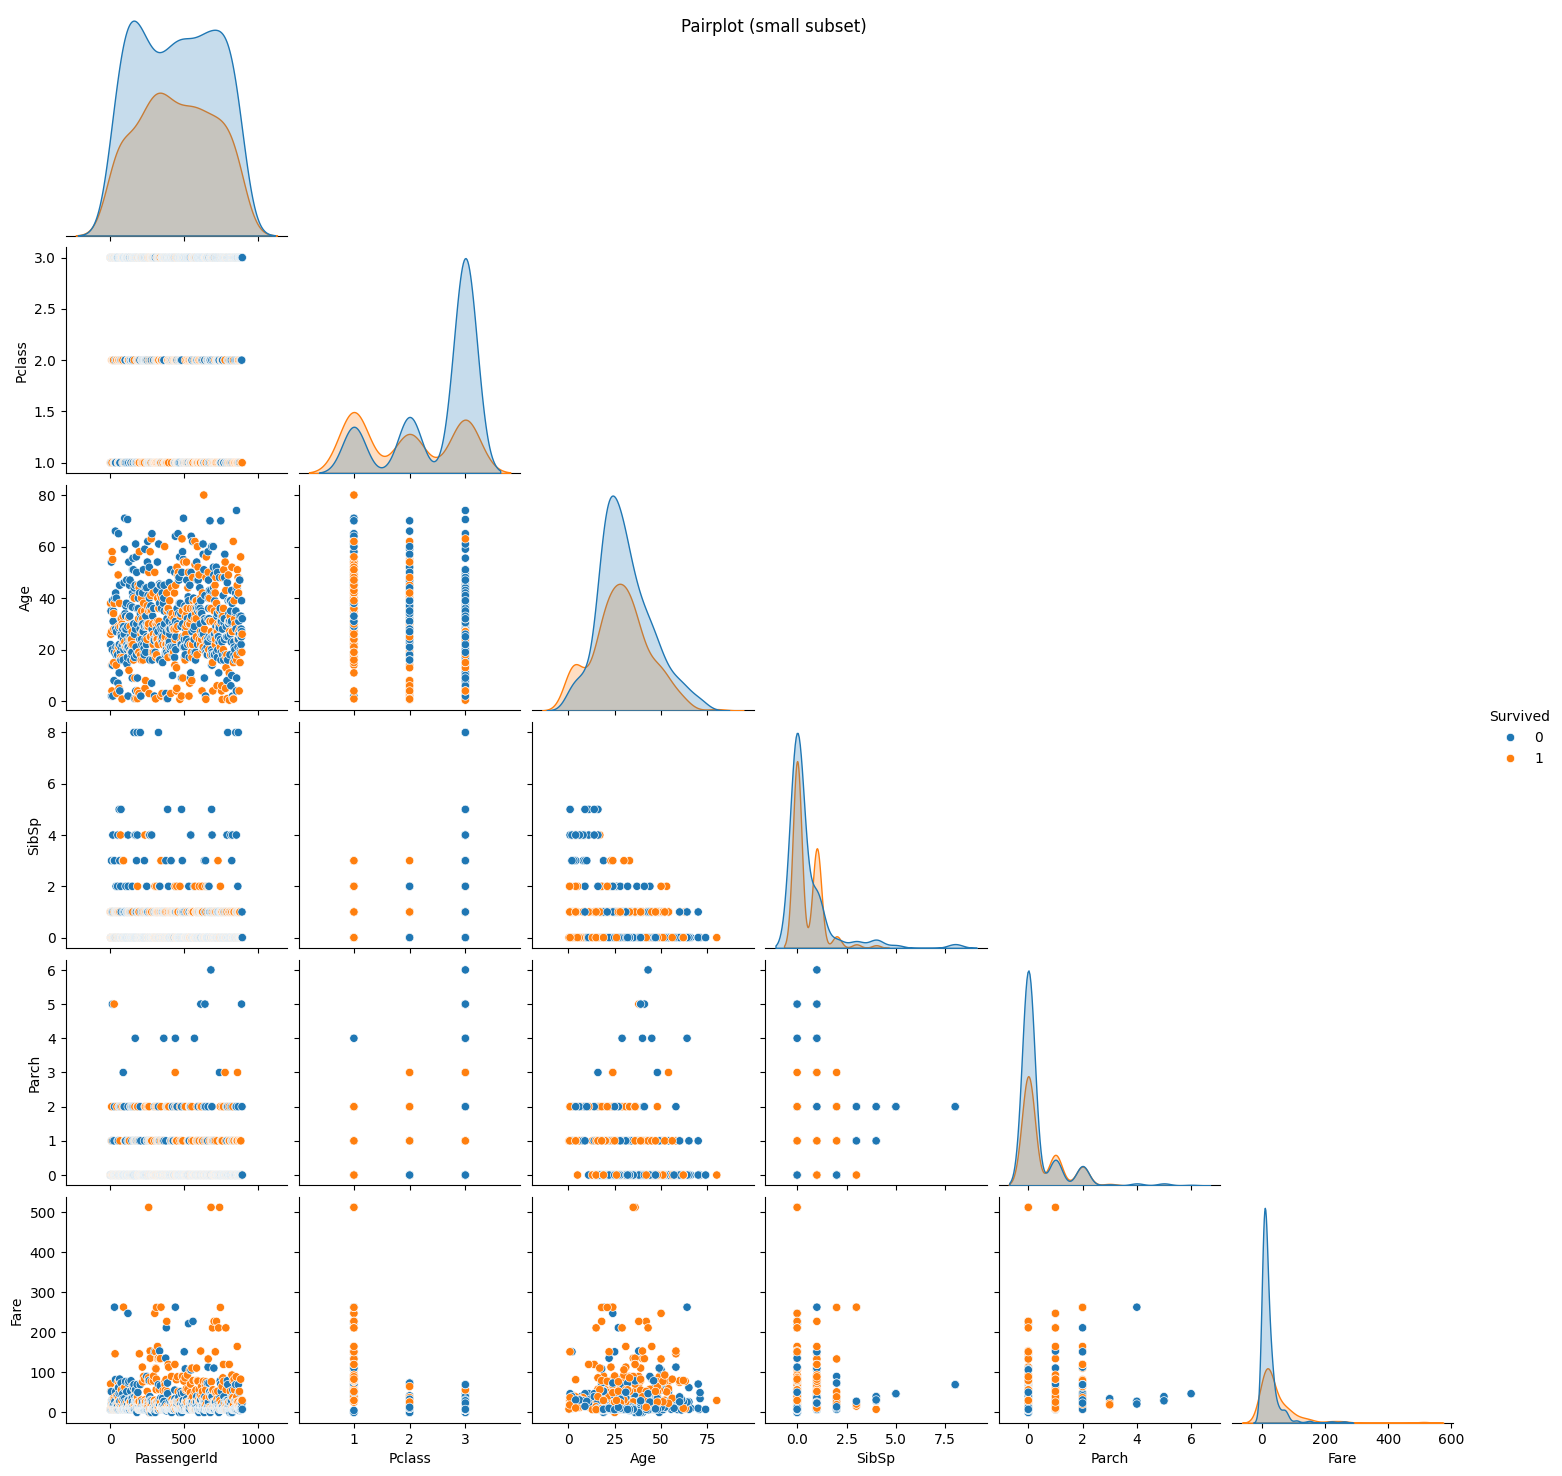

In [96]:
sns.pairplot(
    titanic_df,
    hue='Survived',
    corner=True
)

plt.suptitle('Pairplot (small subset)')
plt.show()

## 2. Identify missing values and perform appropriate imputation

In [97]:
display(titanic_df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Out of all the columns, only age, cabin, and embarked has missing values. The number of missing values are too large to be dropped so we impute.

In [98]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

For the age, I used the median to impute ages since the mean is susceptible to outliers.

In [99]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

For the embarked (port where the passenger boarded), since the value is categorical, I imputed the mode or the most frequently occuring value.

In [100]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[0]
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')

For the cabin, I figured the specific room number is not really important, but the important is the letter included in the cabin which specifies a specific location in the ship. I purposefully put Unknown in the missing cabin values and only took the first letter for those where it is known.

In [101]:
display(titanic_df.isnull().sum())
display(titanic_df.head())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


No more missing values !! ^_^

## 3. Convert categorical variables

The only categorical variables in the dataset are name, sex, ticket, cabin, and embarked. I will not convert name because that's most likely not be useful in the analysis. All are nominal so I will use one-hot encoding.

In [102]:
titanic_df = pd.get_dummies(titanic_df, columns=['Sex'], drop_first=True)

In [103]:
titanic_df['Ticket_prefix'] = titanic_df['Ticket'].str.extract(r'^([A-Za-z./]+)')

titanic_df['Ticket_prefix'] = titanic_df['Ticket_prefix'].str.upper()

titanic_df['Ticket_prefix'] = titanic_df['Ticket_prefix'].replace({
    'A/': 'A',
    'A./': 'A',
    'A.': 'A',
    'CA.': 'CA',
    'S.C./A.': 'SC',
    'S.C.': 'SC',
    'SC/AH': 'SC',
    'SOTON/OQ': 'SOTON',
    'SOTON/O': 'SOTON',
    'SO/C': 'SOTON',
    'S.O.C.': 'SOTON',
    'S.O.P.': 'SOTON',
    'S.O./P.P.': 'SOTON',
    'W./C.': 'WC',
    'W/C': 'WC',
    'WE/P': 'WC',
    'SW/PP': 'WC',
    'S.W./PP': 'WC',
    'F.C.': 'FC',
    'F.C.C.': 'FC',
    'P/PP': 'PP',
    'C.A./SOTON': 'CA',
})

titanic_df['Ticket_prefix'] = titanic_df['Ticket_prefix'].fillna('NUMERIC')

freq = titanic_df['Ticket_prefix'].value_counts()
rare = freq[freq < 5].index

titanic_df['Ticket_prefix'] = titanic_df['Ticket_prefix'].replace(rare, 'OTHER')

titanic_df = pd.get_dummies(titanic_df, columns=['Ticket_prefix'], drop_first=True)

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Ticket_prefix_NUMERIC,Ticket_prefix_OTHER,Ticket_prefix_PC,Ticket_prefix_PP,Ticket_prefix_SC,Ticket_prefix_SC/PARIS,Ticket_prefix_SOTON,Ticket_prefix_SOTON/O.Q.,Ticket_prefix_STON/O,Ticket_prefix_WC
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,...,False,False,False,False,False,False,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C,...,False,False,True,False,False,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,...,False,False,False,False,False,False,False,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C,...,True,False,False,False,False,False,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,...,True,False,False,False,False,False,False,False,False,False


Basically here, I just simplified the ticket column because there are hundreds of unique values of tickets but the prefixes vary even though they are just off by characters (ex: CA. and CA, techinically the same but may be a typo). This simplified from hundreds of unique values to 15.

In [104]:
titanic_df = pd.get_dummies(titanic_df, columns=['Cabin'], drop_first=True)

In [105]:
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)

In [107]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,...,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_Unknown,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,...,False,False,False,False,False,False,False,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,...,False,True,False,False,False,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,...,False,False,False,False,False,False,False,True,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,...,False,True,False,False,False,False,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,...,False,False,False,False,False,False,False,True,False,True


### 4. Split Dataset to train and test sets

In [108]:
X = titanic_df.drop(columns=["Survived", "Name", "Ticket"])
y = titanic_df["Survived"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Regression train/test sizes:', Xr_train.shape, Xr_test.shape)

Regression train/test sizes: (712, 31) (179, 31)


## 5. Train at least two classification models

I plan to do logistic regression and decision tree.

In [109]:
# for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(Xr_train, yr_train)
log_yr_pred = logreg.predict(Xr_test)

log_yr_proba = logreg.predict_proba(Xr_test)[:, 1]

In [110]:
# for decision tree
from sklearn.tree import DecisionTreeClassifier

dt = make_pipeline(
    DecisionTreeClassifier(max_depth=5, random_state=42)
)

dt.fit(Xr_train, yr_train)

tree_yr_pred = dt.predict(Xr_test)
tree_yr_proba = dt.predict_proba(Xr_test)[:, 1]

## 6. Describe how the models work


*   The logistic regression model takes a weighted sum of features and converts them into probabilities using the sigmoid function. I figured this is an ideal model to use since survival is dichotomous, just 0 or 1.
*   Decision tree models ask multiple questions or classifiers, splitting through the data into groups until it can decide survival. I figured that this is also ideal because other than it is simple, it is a good classifier.



## 7. Evaluate the models using accuracy, precision, recall, F1 score, and a confusion matrix.

Logistic Regression classification metrics:
Accuracy: 0.7877094972067039
Precision: 0.7384615384615385
Recall: 0.6956521739130435
F1: 0.7164179104477612

Confusion Matrix:


array([[93, 17],
       [21, 48]])

Text(0.5, 1.0, 'Confusion Matrix for Logistic Regression')

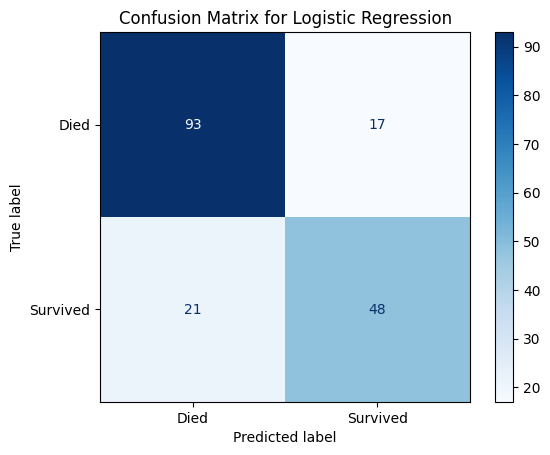

In [111]:
# for the linear regression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

print('Logistic Regression classification metrics:')
print('Accuracy:', accuracy_score(yr_test, log_yr_pred))
print('Precision:', precision_score(yr_test, log_yr_pred))
print('Recall:', recall_score(yr_test, log_yr_pred))
print('F1:', f1_score(yr_test, log_yr_pred))
print('\nConfusion Matrix:')

cm = confusion_matrix(yr_test, log_yr_pred, labels=[0, 1])
display(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')

Logistic Regression classification metrics:
Accuracy: 0.7653631284916201
Precision: 0.7213114754098361
Recall: 0.6376811594202898
F1: 0.676923076923077

Confusion Matrix:


array([[93, 17],
       [25, 44]])

Text(0.5, 1.0, 'Confusion Matrix for Decision Tree Regression')

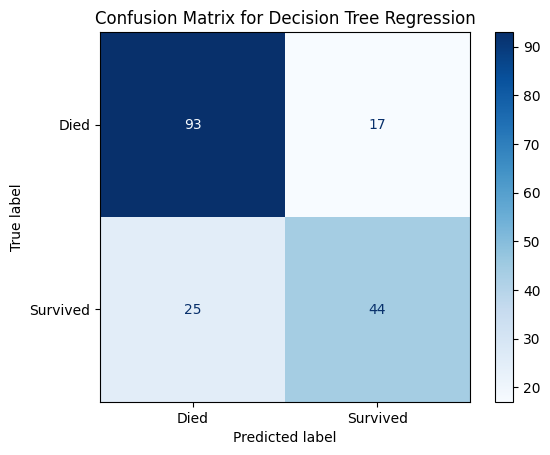

In [112]:
# for the decision tree

print('Logistic Regression classification metrics:')
print('Accuracy:', accuracy_score(yr_test, tree_yr_pred))
print('Precision:', precision_score(yr_test, tree_yr_pred))
print('Recall:', recall_score(yr_test, tree_yr_pred))
print('F1:', f1_score(yr_test, tree_yr_pred))
print('\nConfusion Matrix:')

cm = confusion_matrix(yr_test, tree_yr_pred, labels=[0, 1])
display(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Decision Tree Regression')

## 8. Create a visualization

we gonna make an ROC curve

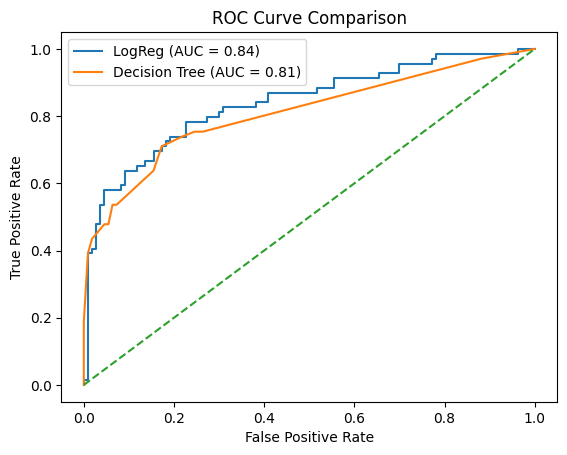

In [113]:
# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(yr_test, log_yr_proba)
auc_lr = auc(fpr_lr, tpr_lr)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(yr_test, tree_yr_proba)
auc_dt = auc(fpr_dt, tpr_dt)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 9. Compare model performances and comment on which model performs better and why.

Comparing model performances, while close, the logistic regression model performed better than the decision tree regressor. The logistic regressor is just better in all metrics; higher accuracy, precision, F1, and recall, higher curve along the ROC, and a higher AUC, meaning it has more true positives overall.

## 10. Write 3-5 insights based on your analysis.


* Overall, the logistic regression model outperformed the decision tree model based on metrics such as accuracy, precision, F1, recall, and ROC analysis.
* The logistic regression and decision tree models yielded the same number of true negatives, both 93 deaths, however the logistic regressor yielded better prediction in survivors, having 4 more true positives than the decision tree model (yun lang).
* In both the models, the models did better at predicting negatives (deaths) than survival. Out of 110 deaths, both properly predicted 93 which is about 85% while the logistic regressor properly predicted 48 out of 69 survivors (70%) and the decision tree regressor properly predicted 44 out of 69 survivors (64%).
* An AUC of above 0.8 for both models implies that both the models are strong at predicting survival in terms of true positives, the logistic regression just had a higher AUC by 0.03 compared to the decision tree (sayang).


## 11. Reflect on which features are more predictive of survival and why

For this, I'll use coefficients and feature importance.

In [114]:
# for logistic regression
features = Xr_train.columns
coefficients = logreg.named_steps['logisticregression'].coef_[0]

importance = pd.DataFrame({
    'feature': features,
    'coefficient': coefficients
}).sort_values(by='coefficient', ascending=False)

display(importance)

,feature,coefficient
19,Ticket_prefix_STON/O,0.294690
24,Cabin_E,0.269285
5,Fare,0.239039
23,Cabin_D,0.193493
7,Ticket_prefix_C,0.164539
25,Cabin_F,0.163514
8,Ticket_prefix_C.A.,0.156072
11,Ticket_prefix_NUMERIC,0.142694
14,Ticket_prefix_PP,0.128798
10,Ticket_prefix_FC,0.100044


From above, we see that the gratest predictors of deaths are sex, passenger class, and age.

So survivability is mostly predicted by demographics and social class such as sex (being male reduces survivability), socioeconomic class (higher chances of survival for upper class),  and age (lesser chance of survival for older people) among others.

Ang random pero naalala ko sa movie ng Titanic may nagsabi "women and chidren first", kaya siguro mas mababa chances of survival ng mga lalaki at matatanda lol.

I mean kung titignan natin yung kwento limited lang yung lifeboats so it could explain why there is only limited survival, and the people they chose to prioritize in these lifeboats are quite clear through the data.

In [115]:
# for decision tree
dt.named_steps['decisiontreeclassifier'].feature_importances_
importance = pd.DataFrame({
    'feature': Xr_train.columns,
    'importance': dt.named_steps['decisiontreeclassifier'].feature_importances_
}).sort_values(by='importance', ascending=False)

display(importance)

,feature,importance
6,Sex_male,0.518084
1,Pclass,0.129183
2,Age,0.111789
5,Fare,0.065654
28,Cabin_Unknown,0.064435
0,PassengerId,0.042680
30,Embarked_S,0.033440
19,Ticket_prefix_STON/O,0.013864
3,SibSp,0.010886
17,Ticket_prefix_SOTON,0.009257


The results are similar with the decision tree, sex, social status, and age are among the greatest predictors of survival.

**Hehe Yon lng po thxx ^___^ !!**

In [116]:
!jupyter nbconvert --to html "/content/drive/MyDrive/DS100 WS2/16_Workshop2.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/DS100 WS2/16_Workshop2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1312776 bytes to /content/drive/MyDrive/DS100 WS2/16_Workshop2.html
